In [452]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [412]:
# load all dataset
# ----------------------------2002------------------------------------->
df_2002 = pd.read_csv("../data/raw/2002.csv")
# ----------------------------2008-------------------------------------->
df_2008 = pd.read_csv("../data/raw/2008.csv",encoding="ISO-8859-1")
# ----------------------------2013-------------------------------------->
df_2013 = pd.read_csv("../data/raw/2013.csv")
# -----------------------------2018-------------------------------------->
df_2018 = pd.read_csv("../data/raw/2018.csv")

In [413]:
# preprocess the data
print(f"dimension 2002: {df_2002.shape}")
print(f"dimension 2008: {df_2008.shape}")
print(f"dimension 2013: {df_2013.shape}")
print(f"dimension 2018: {df_2018.shape}")

dimension 2002: (1793, 11)
dimension 2008: (2316, 11)
dimension 2013: (4542, 12)
dimension 2018: (3428, 12)


Data Info

In [414]:
print("2002",df_2002.info())
print("2008",df_2008.info())
print("2013",df_2013.info())
print("2018",df_2018.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   District                 1793 non-null   object 
 1   Seat                     1793 non-null   object 
 2   Constituency_title       1793 non-null   object 
 3   Candidate_Name           1793 non-null   object 
 4   Party                    1793 non-null   object 
 5   Votes                    1793 non-null   int64  
 6   Total_Valid_Votes        1793 non-null   int64  
 7   Total_Rejected_Votes     1793 non-null   int64  
 8   Total_Votes              1793 non-null   int64  
 9   Total_Registered_Voters  1793 non-null   int64  
 10  Turnout                  1793 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 154.2+ KB
2002 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2316 entries, 0 to 2315
Data columns (total 11 columns):
 #   Colum

We are all set with first issue. Turnout column has % symbol in it which makes it object datatype. We will remove non-numeric characters and change datatype.

Change the datatype of Turnout column

In [415]:
df_2008['Turnout'] = df_2008['Turnout'].str.replace('%', '', regex=False).astype(float)
df_2013['Turnout'] = df_2013['Turnout'].str.replace('%', '', regex=False).astype(float)
df_2018['Turnout'] = df_2018['Turnout'].str.replace('%', '', regex=False).astype(float)

In [416]:
# we replace the column name but value we can extrac from seat column
df_2008.rename(columns={'Unnamed: 0':'District'}, inplace=True)
df_2013.rename(columns={'Unnamed: 0':'District'}, inplace=True)
df_2018.drop('Unnamed: 0', axis=1, inplace=True)
# print("2008: ", df_2008.columns, "\n2013: ", df_2013.columns, "\n2018", df_2018.columns)

In [417]:
# show how to look like columns 
print(f"columns 2002 : \n{df_2002.columns.tolist()}")
print(f"columns 2008 : \n{df_2008.columns.tolist()}")
print(f"columns 2013 : \n{df_2013.columns.tolist()}")
print(f"columns 2018 : \n{df_2018.columns.tolist()}")

columns 2002 : 
['District', 'Seat', 'Constituency_title', 'Candidate_Name', 'Party', 'Votes', 'Total_Valid_Votes', 'Total_Rejected_Votes', 'Total_Votes', 'Total_Registered_Voters', 'Turnout']
columns 2008 : 
['District', 'Seat', 'ConstituencyTitle', 'CandidateName', 'Party', 'Votes', 'TotalValidVotes', 'TotalRejectedVotes', 'TotalVotes', 'TotalRegisteredVoters', 'Turnout']
columns 2013 : 
['District', 'Seat', 'ConstituencyTitle', 'CandidateName', 'Party', 'Votes', 'TotalValidVotes', 'TotalRejectedVotes', 'TotalVotes', 'TotalRegisteredVoters', 'Turnout', 'Unnamed: 11']
columns 2018 : 
['district', 'Seat', 'Constituency_Title', 'Candidate_Name', 'Part', 'Votes', 'Total_Valid_Votes', 'Total_Rejected_Votes', 'Total_Votes', 'Total_Registered_Voters', 'Turnout']


In [418]:
df_2008['District'] = df_2008['Seat'].str.replace('[^A-Za-z ]', '', regex=True)\
                                     .str.replace(r'(?:[0-9IVX]+)$', '', regex=True)\
                                     .str.strip()

df_2013['District'] = df_2013['Seat'].str.replace('[^A-Za-z ]', '', regex=True)\
                                     .str.replace(r'(?:[0-9IVX]+)$', '', regex=True)\
                                     .str.strip()
df_2013 = df_2013.drop(columns= ['Unnamed: 11'], axis=1)
df_2013['District'].unique()

array(['PESHAWAR', 'NOWSHERA', 'CHARSADDA', 'MARDAN', 'SWAB', 'KOHAT',
       'KARAK', 'HANGU', 'ABBOTTABAD', 'HARIPUR', 'MANSEHRA',
       'Tor Ghar cum Mansehra', 'BATTAGRAM', 'KOHISTAN',
       'DERA ISMAIL KHAN', 'DIKHANCUMTANK', 'BANNU', 'LAKKI MARWAT',
       'BUNER', 'SWAT', 'SHANGLA', 'CHITRAL',
       'UPPER DIRCUMLOWER DIN OLD UPPER DIR', 'LOWER DIR',
       'MALAKAND P AREA', 'TRIBAL AREA', 'ISLAMABAD', 'RAWALPIND',
       'ATTOCK', 'CHAKWAL', 'JHELUM', 'SARGODHA', 'KHUSHAB', 'MIANWAL',
       'BHAKKAR', 'FAISALABAD', 'ChiniotI Old  NA Jhang',
       'ChiniotII CumJhang Old NA Jhang',
       'Jhang  CumChiniot Old NA Jhang', 'JhangI Old NA Jhang',
       'JhangII Old NA Jhang', 'JhangIIIOld NA Jhang', 'TOBA TEK SINGH',
       'GUJRANWALA', 'HAFIZABAD', 'GUJRAT', 'MANDI BAHAUDDIN', 'SIALKOT',
       'NAROWAL', 'LAHORE', 'SHEIKHUPURA',
       'SheikhupuraIIcumNankana Sahib Old  Sheikhupura', 'Sheikhupura',
       'Nankana SahibICumSheikhupura Old Sheikhupura',
       'Nankana 

In [419]:
df_2013

,District,Seat,ConstituencyTitle,CandidateName,Party,Votes,TotalValidVotes,TotalRejectedVotes,TotalVotes,TotalRegisteredVoters,Turnout
0,PESHAWAR,PESHAWAR-I,NA-1,Aamir Shehzad Hashmi,Mustaqbil Pakistan,77,145924,2103,146044,320578,46.18
1,PESHAWAR,PESHAWAR-I,NA-1,Akram Khan,Independent,182,145924,2103,146044,320578,46.18
2,PESHAWAR,PESHAWAR-I,NA-1,Alhaaj Ghulam Ahmad Bilour,Awami National Party,24468,145924,2103,146044,320578,46.18
3,PESHAWAR,PESHAWAR-I,NA-1,Amir Syed,Pakistan Peoples Party (Shaheed Bhutto),454,145924,2103,146044,320578,46.18
4,PESHAWAR,PESHAWAR-I,NA-1,Bashir Ahmad Afridi,Muttahida Qaumi Movement Pakistan,117,145924,2103,146044,320578,46.18
...,...,...,...,...,...,...,...,...,...,...,...
4537,Karachi,Karachi,Karachi XVI,NA-254,Muhammad Hussain Khan,Independent,76,177607,1364,178971,309295.00
4538,Karachi,Karachi,Karachi XVI,NA-254,Muhammad Rustam Qadri,Independent,66,177607,1364,178971,309295.00
4539,Karachi,Karachi,Karachi XVI,NA-254,Shabbir Ahmad Qaim Khani,Independent,34,177607,1364,178971,309295.00
4540,Karachi,Karachi,Karachi XVI,NA-254,Muhammad Arif Khan,Independent,29,177607,1364,178971,309295.00


In [420]:
df_2013.isnull().sum()

District                 0
Seat                     0
ConstituencyTitle        0
CandidateName            0
Party                    0
Votes                    0
TotalValidVotes          0
TotalRejectedVotes       0
TotalVotes               0
TotalRegisteredVoters    0
Turnout                  0
dtype: int64

In [421]:
# Checkout the null values
print(df_2002.isnull().sum().sum())
print(df_2008.isnull().sum().sum())
print(df_2013.isnull().sum().sum())
print(df_2018.isnull().sum().sum())


0
0
0
0


df_2013 has one null value

In [422]:

df_2013.isnull().sum().sum()

np.int64(0)

In [423]:
# standardize the columnns Name - unify them

def clean_columns(df):
   df = df.rename(columns= {
        'Constituency_title': 'ConstituencyTitle',
        'Constituency_Title': 'ConstituencyTitle',

        'Candidate_Name': 'CandidateName',
        'Part' : 'Party',
        'district':'District',

        'Total_Valid_Votes':'TotalValidVotes',
        'Total_Rejected_Votes':'TotalRejectedVotes',
        'Total_Votes':'TotalVotes',

        'Total_Registered_Voters':'TotalRegisteredVoters'

    }
    )

   df = df.loc[:, ~df.columns.str.contains("Unnamed")]
   return df

In [424]:
df_2002 = clean_columns(df_2002)
df_2008 = clean_columns(df_2008)
df_2013 = clean_columns(df_2013)
df_2018 = clean_columns(df_2018)


In [425]:
# Adding Year Columns
df_2002["Year"] = 2002
df_2008["Year"] = 2008
df_2013["Year"] = 2013
df_2018["Year"] = 2018


In [426]:
# Concatenate All Dataset
df = pd.concat([df_2002, df_2008, df_2013, df_2018])
print(f"Dimension :{df.shape}")

Dimension :(12079, 12)


In [427]:
# check out columns
df.columns.to_list()

['District',
 'Seat',
 'ConstituencyTitle',
 'CandidateName',
 'Party',
 'Votes',
 'TotalValidVotes',
 'TotalRejectedVotes',
 'TotalVotes',
 'TotalRegisteredVoters',
 'Turnout',
 'Year']

In [428]:
df  = df.dropna(subset =['District'], axis =0)

In [429]:
# Remove the unncessory columns
df.isnull().any()

District                 False
Seat                     False
ConstituencyTitle        False
CandidateName            False
Party                    False
Votes                    False
TotalValidVotes          False
TotalRejectedVotes       False
TotalVotes               False
TotalRegisteredVoters    False
Turnout                  False
Year                     False
dtype: bool

*Text Pre-Processing*

In [430]:

dist = df['District'].unique()
dist

array(['PESHAWAR', 'NOWSHERA', 'Nowshera', 'Charsadda', 'Charsdda',
       'Mardan', 'Sawabi', 'Kohat', 'Karak', 'Hangu', 'Abbottabad',
       'Haripur', 'Mansehra', 'Batagram', 'Kohistan', 'Dera Ismail Khan',
       'Dera Ismail Khan cum Tank', 'Bannu', 'Lakki Marwat', 'Buner',
       'Sawat', 'Shangla', 'Chitral', 'Upper Dir', 'Lower Dir',
       'Malakand', 'Tribal Area', 'Islamabad', 'Rawalpindi', 'Attock',
       'Chakwal', 'Jhelum', 'Sargodha', 'Khushab', 'khushab', 'Mianwali',
       'Bhakkar', 'Faisalabad', 'Jhang', 'Toba Tek Singh', 'Gujranwala',
       'Hafizabad', 'Gujrat', 'Mandi Bahauddin', 'Sialkot', 'Narowal',
       'Lahore', 'Sheikhupura', 'Sheiklhupura', 'Kasur', 'Okara',
       'Multan', 'Lodhran', 'Khanewal', 'Sahiwal', 'Pakpattan', 'Vehari',
       'Dera Ghazi Khan', 'Rajanpur', 'Muzaffargarh', 'Layyah',
       'Bahawalpur', 'Bahawalnagar', 'Rahimyar Khan', 'SUKKUR', 'Ghotki',
       'Shikarpur', 'Shikarapur', 'Larkana', 'Jacobabad',
       'Nausheroferoze', 'Nawab

In [431]:
# convert into lower
df['District'] = df['District'].str.lower()
# remove the whitespace
df['District'] = df['District'].str.strip()

In [432]:
dist = df['District'].unique()
#dist.sort()
dist

array(['peshawar', 'nowshera', 'charsadda', 'charsdda', 'mardan',
       'sawabi', 'kohat', 'karak', 'hangu', 'abbottabad', 'haripur',
       'mansehra', 'batagram', 'kohistan', 'dera ismail khan',
       'dera ismail khan cum tank', 'bannu', 'lakki marwat', 'buner',
       'sawat', 'shangla', 'chitral', 'upper dir', 'lower dir',
       'malakand', 'tribal area', 'islamabad', 'rawalpindi', 'attock',
       'chakwal', 'jhelum', 'sargodha', 'khushab', 'mianwali', 'bhakkar',
       'faisalabad', 'jhang', 'toba tek singh', 'gujranwala', 'hafizabad',
       'gujrat', 'mandi bahauddin', 'sialkot', 'narowal', 'lahore',
       'sheikhupura', 'sheiklhupura', 'kasur', 'okara', 'multan',
       'lodhran', 'khanewal', 'sahiwal', 'pakpattan', 'vehari',
       'dera ghazi khan', 'rajanpur', 'muzaffargarh', 'layyah',
       'bahawalpur', 'bahawalnagar', 'rahimyar khan', 'sukkur', 'ghotki',
       'shikarpur', 'shikarapur', 'larkana', 'jacobabad',
       'nausheroferoze', 'nawabshah', 'khairpur', 'hyd

In [433]:
import fuzzywuzzy 
from fuzzywuzzy import process
import chardet
from subprocess import check_output

In [434]:
matches = fuzzywuzzy.process.extract('charsadda', dist, limit = 10, scorer = fuzzywuzzy.fuzz.token_sort_ratio)
matches

[('charsadda', 100),
 ('charsdda', 94),
 ('mardan', 53),
 ('tharparkar', 53),
 ('chagai', 53),
 ('chakwal', 50),
 ('larkana', 50),
 ('rahimyar khan', 45),
 ('hafizabad', 44),
 ('jacobabad', 44)]

In [435]:
def replace_matches_in_column(df, column, string_to_match, min_ratio = 90):
    # get a list of unique strings
    strings = df[column].unique()
    
    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings, 
                                         limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

    # only get matches with a ratio > 90
    close_matches = [matches[0] for matches in matches if matches[1] >= min_ratio]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches 
    df.loc[rows_with_matches, column] = string_to_match

In [436]:
from fuzzywuzzy import process
import fuzzywuzzy.fuzz
dict = df.District.unique()

matche = process.extract('charsadda', dict, limit=3, scorer = fuzzywuzzy.fuzz.token_sort_ratio)
matche

[('charsadda', 100), ('charsdda', 94), ('mardan', 53)]

In [437]:
from fuzzywuzzy import process, fuzz

def replace_matche_words_in_column(df, column, string_to_match, min_ratio=90):

    # list of words in the column
    uni_words = df[column].astype(str).unique()

    # find closest matches
    matches = process.extract(string_to_match, uni_words, limit=10, scorer=fuzz.token_sort_ratio)

    # keep matches above threshold
    close_matches = [m[0] for m in matches if m[1] >= min_ratio]

    # replace all matching rows
    df.loc[df[column].isin(close_matches), column] = string_to_match

    return df


In [438]:
districts = [
    "charsadda",
    "nowshera",
    "rawalpindi",
    "sheikhupura",
    "shikarpur",
    "nankana sahib"
]
for dist in districts:
        replace_matche_words_in_column(df = df, column='District', string_to_match= dist)

In [439]:
# uncommend the code the see 
# df.District.unique()

In [440]:
pty = df['Party'].unique()
# sort on alphabtical order 
pty.sort()
pty

array(['Aam Admi Tehreek Pakistan', 'Aam Awam Party',
       'Aam Log Party Pakistan', 'Aap Janab Sarkar Party',
       'Adnan Anwar Rehmani', 'Afghan Qumi Movement (Pakistan)',
       'All Pakistan Bayrozgar Party', 'All Pakistan Muslim League',
       'All Pakistan Muslim League (jinnah)', 'All Pakistan Tehreek',
       'All Pakistan Youth Working Party', 'Allah-o-Akbar Tehreek',
       'Amun Taraqqi Party', 'Awam League',
       'Awami Himayat Tehreek Pakistan', 'Awami Jamhuri Ittehad Pakistan',
       'Awami Justice Party', 'Awami Justice Party Pakistan',
       'Awami Muslim League Pakistan', 'Awami National Party',
       'Awami Qaidat Party', 'Awami Qiadat Party', 'Awami Workers Party',
       'Azad Pakistan Party', 'Bahawalpur National Awami Party',
       'Balochistan Awami Party', 'Balochistan National Congress',
       'Balochistan National Democratic Party',
       'Balochistan National Movement', 'Balochistan National Party',
       'Balochistan National Party (Awami)',
  

In [441]:
#converting text to lower case & removing white spaces
df['Party'] = df['Party'].str.lower()
df['Party'] = df['Party'].str.strip()

In [442]:
party_list = {
    "balochistan national movement": 90,
    "independent": 90,
    "istiqlal party": 90,
    "jamote qaumi movement": 90,
    "labour party pakistan": 90,
    "mohib-e-wattan nowjawan inqilabion ki anjuman (mnaka)": 90,
    "muttahida qaumi movement": 90,
    "muttahidda majlis-e-amal": 90,
    "national peoples party": 90,
    "nizam-e-mustafa party": 90,
    "pak muslim alliance": 90,
    "pakistan awami party": 90,
    "pakistan democratic party": 90,
    "pakistan muslim league (qa)": 97,
    "pakistan muslim league (n)": 97,
    "pakistan muslim league (j)": 97,
    "pakistan muslim league (f)": 97,
    "pakistan peoples party parliamentarians": 97,
    "pakistan peoples party(shaheed bhutto)": 95,
    "pakistan peoples party(sherpao)": 97,
    "pakistan tehreek-e-insaf": 95,
    "saraiki sooba movement pakistan": 95
}
for party, ratio in party_list.items():
   replace_matche_words_in_column(df, 'Party', party, min_ratio=ratio)

In [443]:
# df.Party.unique()

In [444]:
party_corrections = {
    'muttahida qaumi movement pakistan': 'muttahida qaumi movement',
    'indeindependentdente': 'independent',
    'independent (retired)': 'independent',
    'indepndent': 'independent',
    'mutthida\xa0majlis-e-amal\xa0pakistan': 'muttahidda majlis-e-amal',
    'mutthidaï¿½majlis-e-amalï¿½pakistan': 'muttahidda majlis-e-amal',
    'muttahidda majlis-e-amal pakistan': 'muttahidda majlis-e-amal',
    'nazim-e-mistafa': 'nizam-e-mustafa party',
    'pakistan muslim league (qa)': 'pakistan muslim league (q)',
    'pakistan muslim league council': 'pakistan muslim league (c)',
    'pakistan muslim league \x93h\x94 haqiqi': 'pakistan muslim league haqiqi',
    'pakistan muslim league(z)': 'pakistan muslim league (z)',
    'pakistan peoples party(shaheed bhutto)': 'pakistan peoples party (shaheed bhutto)',
    'pakistan sariaki party': 'pakistan siraiki party (t)',
    'pasban': 'pasban pakistan',
    'qaumi watan party (sherpao)': 'qaumi watan party',
    'tehreek-e-suba hazara': 'tehreek-e-suba hazara pakistan',
    'pashtoonkhwa milli awami party': 'pakhtoonkhwa milli awami party',
    'pakistan amn party': 'pakistan aman party',
    'pakistan awami inqelabi': 'pakistan awami inqelabi league',
    'pakistan freedom party': 'pakistan freedom movement',
    'pakistan insani haqook party (pakistan human rights party)': 'pakistan human rights party',
    'awami justice party': 'awami justice party pakistan',
    'indeindependentdent': 'independent',
    'jamiat ulama-e-pakistan  (noorani)': 'jamiat ulama-e-pakistan (noorani)',
    'jumiat ulma-e-islam(nazryati)': 'jamiat ulma-e-islam nazryati pakistan',
    'majlis-e-wahdat-e-muslimeen pakistan': 'majlis wahdat-e-muslimeen pakistan',
    'markazi jamat-al-hadais': 'markazi jamiat ahl-e-hadith',
    'aam admi tehreek pakistan': 'aam awam party',
    'aam log party pakistan':'aam awam party',
    'awami qiadat party':'awami qaidat party',
    'pasban pakistan.':"pasban pakistan",
    'pakistan peoples party parliamentarian':"pakistan peoples party parlimentarian",
    'pakistan peoples party parliamentarians':"pakistan peoples party parlimentarian",
    'pakistan peoples party parlimentarians':"pakistan peoples party parlimentarian",
    'pakistan tahreek-e-insaf':"pakistan tehreek-e-insaf",
    'mohib-e-wattan nowjawan inqilabion ki anjuman (mnaka)': 'muhib-e-watan noujawan anqlabion ki anjuman (mnaka)'
}
df['Party'] = df['Party'].replace(party_corrections)
pty = sorted(df['Party'].unique())
pty

['aam awam party',
 'aap janab sarkar party',
 'adnan anwar rehmani',
 'afghan qumi movement (pakistan)',
 'all pakistan bayrozgar party',
 'all pakistan muslim league',
 'all pakistan muslim league (jinnah)',
 'all pakistan tehreek',
 'all pakistan youth working party',
 'allah-o-akbar tehreek',
 'amun taraqqi party',
 'awam league',
 'awami himayat tehreek pakistan',
 'awami jamhuri ittehad pakistan',
 'awami justice party pakistan',
 'awami muslim league pakistan',
 'awami national party',
 'awami qaidat party',
 'awami workers party',
 'azad pakistan party',
 'bahawalpur national awami party',
 'balochistan awami party',
 'balochistan national congress',
 'balochistan national democratic party',
 'balochistan national movement',
 'balochistan national party',
 'balochistan national party (awami)',
 'barabri party pakistan',
 'ch. abid ali',
 'chaudhary munawar hafeez',
 'christian progressive movement',
 'communist party of pakistan',
 'doctor khalid imtiaz khan baloch',
 'farrukh 

In [445]:
#convert textual content to lower case & remove trailing white spaces
df['CandidateName'] = df['CandidateName'].str.lower()
df['CandidateName'] = df['CandidateName'].str.strip()
df['CandidateName'].head(10)

0                     mr sajid abdullah
1                       mr shabir ahmad
2                mr usman bashir bilour
3    mr muhammad khurshid khan advocate
4              mr muhammad muazzam butt
5                 dr arbab alamgir khan
6     mr abdul manan akhunzada advocate
7                  maulana rehmat ullah
8            mr arbab muhammad ayub jan
9                 mr iqbal zafar jhagra
Name: CandidateName, dtype: object

In [446]:
# Remove 'mr ', 'mrs ', 'miss ' at the beginning (case-insensitive)
df['CandidateName'] = df['CandidateName'].str.replace(r'^(mr |mrs |miss )', '', regex=True, case=False)

df['CandidateName'] 

0                        sajid abdullah
1                          shabir ahmad
2                   usman bashir bilour
3       muhammad khurshid khan advocate
4                 muhammad muazzam butt
                     ...               
3423                     mohammad akram
3424             muhammad akhtar mengal
3425                 nawab khan bizenjo
3426                      shakeel ahmed
3427                wazeer ahmed norani
Name: CandidateName, Length: 12079, dtype: object

In [447]:
# step 1:find the winner for each constituency and year
df_winner =df.loc[df.groupby(['ConstituencyTitle','Year'])['Votes'].idxmax()]
df_winner


,District,Seat,ConstituencyTitle,CandidateName,Party,Votes,TotalValidVotes,TotalRejectedVotes,TotalVotes,TotalRegisteredVoters,Turnout,Year
4517,faislabad,Faislabad,FAISALABAD-X,na-84,rana muhammad saeed khan,TTP,291,180530,2805,203378,311576.00,2013
4528,karachi,Karachi,Karachi XVI,na-254,muhammad naeem,PTI,5855,177607,1364,178971,309295.00,2013
1,peshawar,PESHAWAR-I,NA-1,shabir ahmad,muttahidda majlis-e-amal,37179,65642,1552,67194,233907,28.73,2002
1,peshawar,Peshawar-1,NA-1,ashoni kumar,independent,156,88325,629,88913,387083,22.97,2008
1,peshawar,PESHAWAR-I,NA-1,akram khan,independent,182,145924,2103,146044,320578,46.18,2013
...,...,...,...,...,...,...,...,...,...,...,...,...
1610,lahore,Lahore-VIII,NA-130,muhammad abu bakar,pakistan quami yakjehti party,414,0,0,0,0,52.99,2018
1261,nawabshah,Nawabshah-II,NA-214,farooque ahmed chandio,independent,999,110802,2754,113556,305810,37.10,2002
1261,multan,Multan-II,NA-149,prof. muhammad amjad khan,independent,1664,65545,1605,126603,427253,29.63,2008
1261,faisalabad,FAISALABAD-II,NA-76,sardar akbar ali dogar advocate,independent,12,185170,6346,191686,329266,58.21,2013


In [448]:
df_final = df_winner.iloc[2:].reset_index(drop=True)
df_final.head()

,District,Seat,ConstituencyTitle,CandidateName,Party,Votes,TotalValidVotes,TotalRejectedVotes,TotalVotes,TotalRegisteredVoters,Turnout,Year
0,peshawar,PESHAWAR-I,NA-1,shabir ahmad,muttahidda majlis-e-amal,37179,65642,1552,67194,233907,28.73,2002
1,peshawar,Peshawar-1,NA-1,ashoni kumar,independent,156,88325,629,88913,387083,22.97,2008
2,peshawar,PESHAWAR-I,NA-1,akram khan,independent,182,145924,2103,146044,320578,46.18,2013
3,chitral,Chitral,NA-1,saeed ur rehman,pakistan rah-e-haq party,3223,0,0,0,0,60.97,2018
4,peshawar,PESHAWAR-II,NA-2,abdul manan akhunzada advocate,pakistan peoples party(sherpao),926,56000,1367,57367,216587,26.49,2002


In [449]:
df_final = df_final.rename(columns = {'Party':'WinningParty'})
df_final.head(2)

,District,Seat,ConstituencyTitle,CandidateName,WinningParty,Votes,TotalValidVotes,TotalRejectedVotes,TotalVotes,TotalRegisteredVoters,Turnout,Year
0,peshawar,PESHAWAR-I,NA-1,shabir ahmad,muttahidda majlis-e-amal,37179,65642,1552,67194,233907,28.73,2002
1,peshawar,Peshawar-1,NA-1,ashoni kumar,independent,156,88325,629,88913,387083,22.97,2008


In [450]:
# drop useless columns
df_final.drop(columns =['Seat','CandidateName'], inplace=True)
df_final

,District,ConstituencyTitle,WinningParty,Votes,TotalValidVotes,TotalRejectedVotes,TotalVotes,TotalRegisteredVoters,Turnout,Year
0,peshawar,NA-1,muttahidda majlis-e-amal,37179,65642,1552,67194,233907,28.73,2002
1,peshawar,NA-1,independent,156,88325,629,88913,387083,22.97,2008
2,peshawar,NA-1,independent,182,145924,2103,146044,320578,46.18,2013
3,chitral,NA-1,pakistan rah-e-haq party,3223,0,0,0,0,60.97,2018
4,peshawar,NA-2,pakistan peoples party(sherpao),926,56000,1367,57367,216587,26.49,2002
...,...,...,...,...,...,...,...,...,...,...
3695,lahore,NA-130,pakistan quami yakjehti party,414,0,0,0,0,52.99,2018
3696,nawabshah,NA-214,independent,999,110802,2754,113556,305810,37.10,2002
3697,multan,NA-149,independent,1664,65545,1605,126603,427253,29.63,2008
3698,faisalabad,NA-76,independent,12,185170,6346,191686,329266,58.21,2013


In [454]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# Count total wins per party
party_wins = df_final['WinningParty'].value_counts()

# Select top 5
top5_parties = party_wins.head(5).index.tolist()
print("Top 5 parties:", top5_parties)



Top 5 parties: ['independent', 'pakistan peoples party parlimentarian', 'pakistan muslim league (n)', 'pakistan tehreek-e-insaf', 'muttahidda majlis-e-amal']


In [455]:
df_top5 = df_final[df_final['WinningParty'].isin(top5_parties)]


C:\Users\HP\AppData\Local\Temp\ipykernel_16080\4197169485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WinningParty', y='Wins', data=top5_counts, palette='viridis')


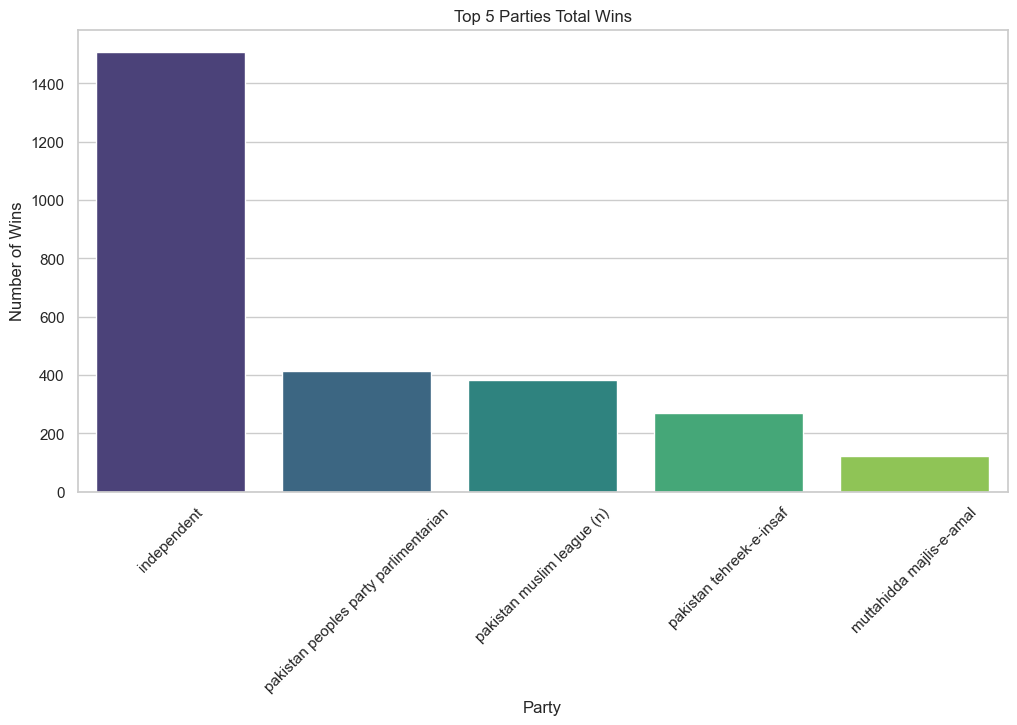

In [457]:
# Count wins per party
top5_counts = df_top5['WinningParty'].value_counts()[top5_parties].reset_index()
top5_counts.columns = ['WinningParty', 'Wins']

# Plot
sns.barplot(x='WinningParty', y='Wins', data=top5_counts, palette='viridis')
plt.title("Top 5 Parties Total Wins")
plt.ylabel("Number of Wins")
plt.xlabel("Party")
plt.xticks(rotation=45)
plt.show()


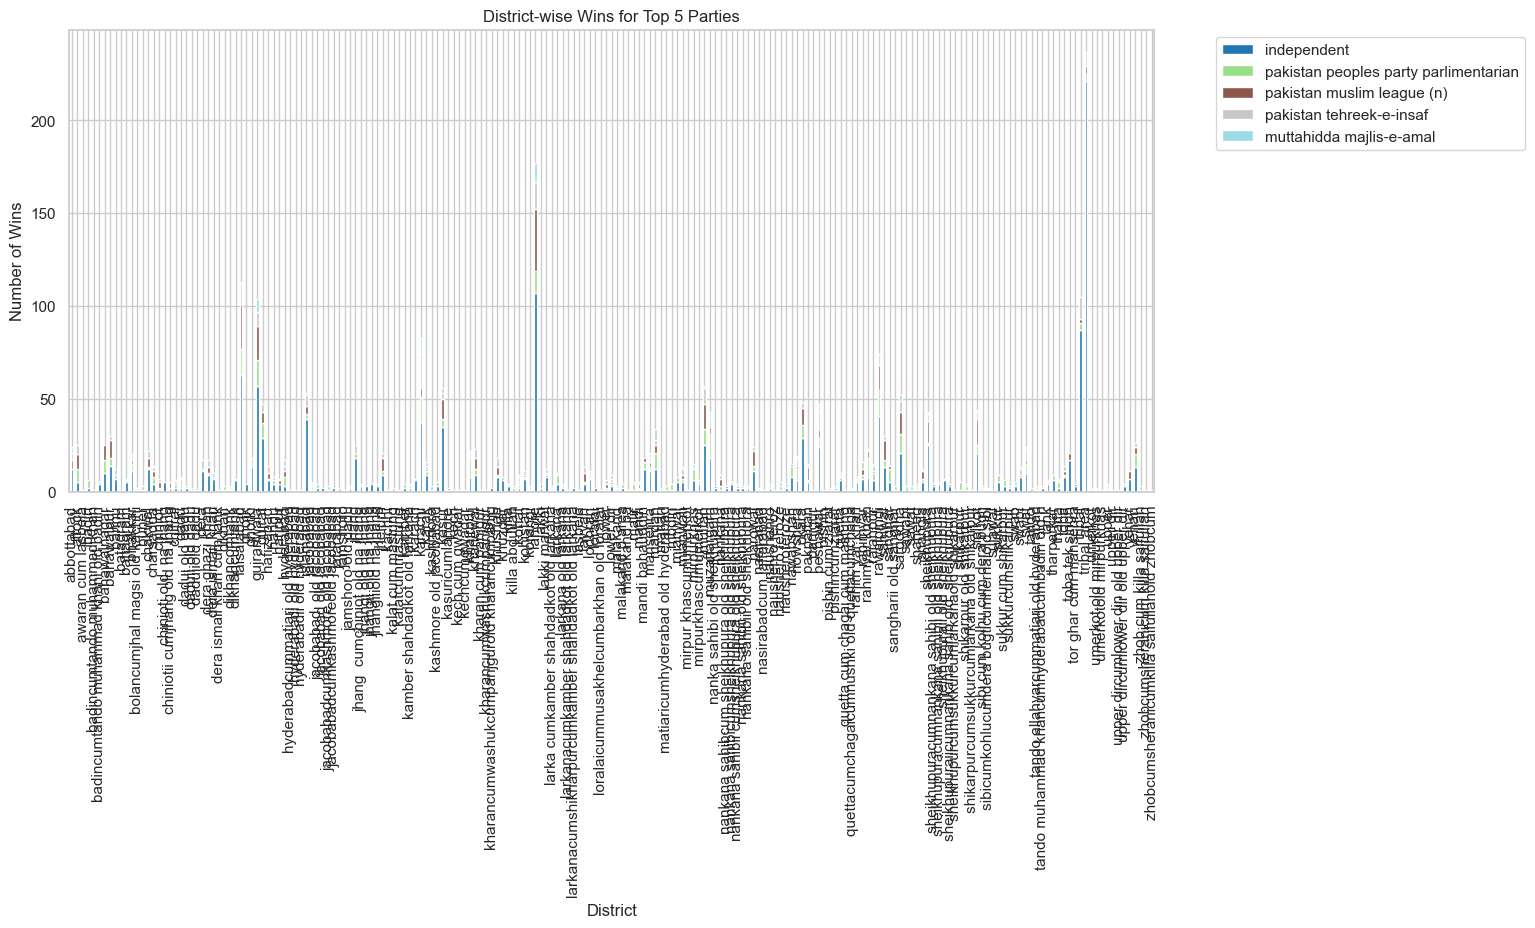

In [458]:
district_summary = df_top5.groupby(['District', 'WinningParty']).size().unstack(fill_value=0)
district_summary = district_summary[top5_parties]  # keep only top 5

district_summary.plot(kind='bar', stacked=True, figsize=(14,6), colormap='tab20')
plt.title("District-wise Wins for Top 5 Parties")
plt.ylabel("Number of Wins")
plt.xlabel("District")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


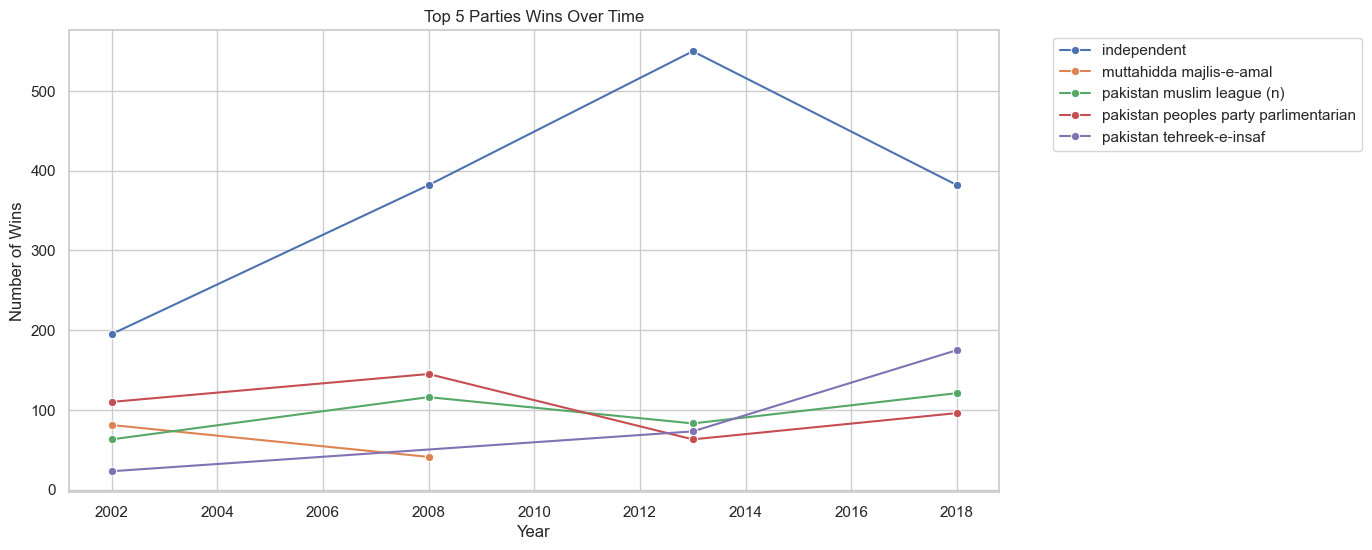

In [459]:
year_party = df_top5.groupby(['Year', 'WinningParty']).size().reset_index(name='Wins')

sns.lineplot(data=year_party, x='Year', y='Wins', hue='WinningParty', marker="o")
plt.title("Top 5 Parties Wins Over Time")
plt.ylabel("Number of Wins")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [465]:
# save the data into csv file
df_final.to_csv('../data/processed/clean_data.csv', index = False)